In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from data import data_loader
from features import tstat, volatility
from regime import state_labels

df = data_loader.get_data()
df = tstat.compute_tstat(df)
df = volatility.compute_volatility(df)
df = state_labels.label_volatility(df)
df = state_labels.label_regime(df)
df = state_labels.smooth_regime(df)

[*********************100%***********************]  1 of 1 completed
/Users/ak/Documents/GitHub/entropy-trading/regime/state_labels.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .apply(lambda x: x[-1] if (x == x[-1]).sum() >= window else np.nan)


In [3]:
df.head()

,Price,Log Return,T-Stat_200,Volatility,Vol State,Regime
Date,,,,,,
2008-01-03,103.728157,-0.000483,NaN,NaN,0,NaN
2008-01-04,101.186165,-0.024812,NaN,NaN,0,NaN
2008-01-07,101.100182,-0.000850,NaN,NaN,0,NaN
2008-01-08,99.467598,-0.016280,NaN,NaN,0,NaN
2008-01-09,100.513039,0.010456,NaN,NaN,0,0.0


In [4]:
df.tail()

,Price,Log Return,T-Stat_200,Volatility,Vol State,Regime
Date,,,,,,
2024-12-24,594.320801,0.011054,1.432930,0.007806,1,1.0
2024-12-26,594.360352,0.000067,1.531647,0.007909,1,1.0
2024-12-27,588.103821,-0.010582,1.443915,0.007804,0,1.0
2024-12-30,581.392639,-0.011477,1.358177,0.007945,1,1.0
2024-12-31,579.277405,-0.003645,1.268186,0.008096,1,1.0


In [5]:
df[['Log Return', 'T-Stat_200', 'Volatility', 'Vol State', 'Regime']].tail(10)

,Log Return,T-Stat_200,Volatility,Vol State,Regime
Date,,,,,
2024-12-17,-0.004128,1.616920,0.006485,0,1.0
2024-12-18,-0.030257,1.587694,0.006517,0,1.0
2024-12-19,-0.000307,1.356802,0.007658,0,1.0
2024-12-20,0.011939,1.310543,0.007650,0,1.0
2024-12-23,0.005970,1.326524,0.007781,0,1.0
2024-12-24,0.011054,1.432930,0.007806,1,1.0
2024-12-26,0.000067,1.531647,0.007909,1,1.0
2024-12-27,-0.010582,1.443915,0.007804,0,1.0
2024-12-30,-0.011477,1.358177,0.007945,1,1.0


In [6]:
df[['Vol State', 'Regime']].dropna().dtypes

Vol State      int64
Regime       float64
dtype: object

In [7]:
df['Log Return'].std()

0.012601546695203577

In [8]:
df['T-Stat_200'].describe()

count    4078.000000
mean        0.861157
std         0.915001
min        -1.691397
25%         0.212675
50%         0.896961
75%         1.620296
max         3.438994
Name: T-Stat_200, dtype: float64

In [9]:
df['Volatility'].describe()

count    4218.000000
mean        0.010684
std         0.006776
min         0.003136
25%         0.006923
50%         0.008619
75%         0.012334
max         0.047614
Name: Volatility, dtype: float64

In [10]:
df.isna().sum()

Price           0
Log Return      0
T-Stat_200    200
Volatility     60
Vol State       0
Regime          4
dtype: int64

In [11]:
df['Regime'].value_counts(normalize = True)

Regime
 1.0    0.507019
 0.0    0.452737
-1.0    0.040243
Name: proportion, dtype: float64

In [12]:
df['Vol State'].value_counts(normalize = True)

Vol State
0    0.767415
1    0.232585
Name: proportion, dtype: float64

<Axes: xlabel='Date', ylabel='T-Stat_200'>

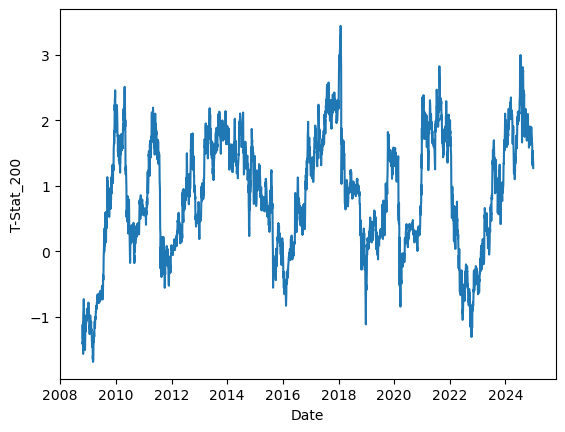

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(data = df['T-Stat_200'])

<Axes: xlabel='Date', ylabel='Volatility'>

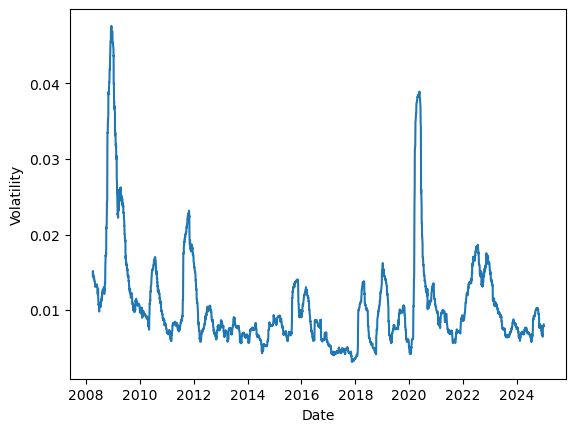

In [14]:
sns.lineplot(data = df['Volatility'])

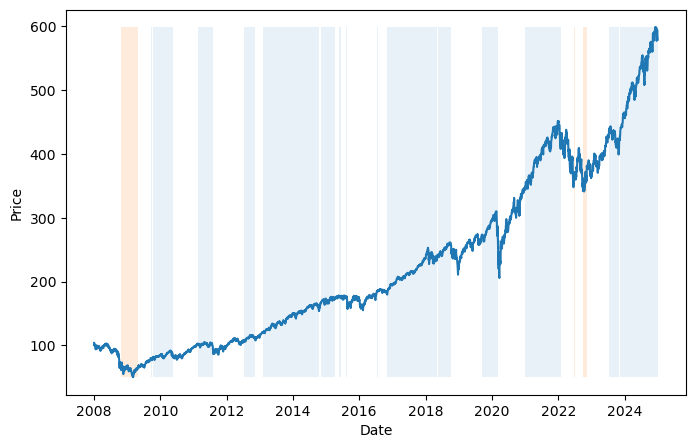

In [15]:
fig, ax = plt.subplots(figsize = (8, 5))
sns.lineplot(data = df['Price'], ax = ax)
ax.fill_between(df.index, df['Price'].min(), df['Price'].max(), where = (df['Regime'] == 1), alpha = 0.1, label = 'Bull')
ax.fill_between(df.index, df['Price'].min(), df['Price'].max(), where = (df['Regime'] == -1), alpha = 0.15, label = 'Bear')

In [16]:
df['Forward Return'] = df['Log Return'].shift(-1)
df_new = df.dropna(subset = ['Forward Return'])

bull_mean = df_new.loc[df['Regime'] == 1, 'Forward Return'].mean()
neutral_mean = df_new.loc[df['Regime'] == 0, 'Forward Return'].mean()
bear_mean = df_new.loc[df['Regime'] == -1, 'Forward Return'].mean()

print(bull_mean)
print(neutral_mean)
print(bear_mean)

df_new.loc[df_new['Regime'] == -1, 'Forward Return'].describe()

0.0004530915432469991
0.0003504168022117689
0.0005351233796499713


count    172.000000
mean       0.000535
std        0.027980
min       -0.092749
25%       -0.014420
50%        0.000288
75%        0.014828
max        0.110517
Name: Forward Return, dtype: float64

In [17]:
df_new.groupby('Regime')['Forward Return'].std()

Regime
-1.0    0.027980
 0.0    0.014299
 1.0    0.008291
Name: Forward Return, dtype: float64

In [18]:
import numpy as np

bear_forward = df_new.loc[df_new['Regime'] == -1, 'Forward Return']

t = bear_forward.mean() / (bear_forward.std() / np.sqrt(len(bear_forward)))
print(t)

0.2508264779754517


In [19]:
bull_forward = df_new.loc[df_new['Regime'] == 1, 'Forward Return']

t = bull_forward.mean() / (bull_forward.std() / np.sqrt(len(bull_forward)))
print(t)

2.5433185869763593


In [20]:
neutral_forward = df_new.loc[df_new['Regime'] == 0, 'Forward Return']

t = neutral_forward.mean() / (neutral_forward.std() / np.sqrt(len(neutral_forward)))
print(t)

1.0779695216919074


In [21]:
df['Forward Vol'] = df['Volatility'].shift(-1)
df_new = df.dropna(subset =['Forward Vol'])

df_new.groupby('Vol State')['Forward Vol'].mean()

Vol State
0    0.009509
1    0.014494
Name: Forward Vol, dtype: float64

In [22]:
from regime import matrix

df = matrix.initialize_state(df)

transition_matrix = matrix.build_stationary_matrix(df)
print(transition_matrix)

Next State    -1.0_0    -1.0_1     0.0_0     0.0_1     1.0_0     1.0_1  nan_0
State                                                                        
-1.0_0      0.972414  0.020690  0.006897  0.000000  0.000000  0.000000   0.00
-1.0_1      0.074074  0.851852  0.000000  0.074074  0.000000  0.000000   0.00
0.0_0       0.001541  0.000000  0.978428  0.010015  0.010015  0.000000   0.00
0.0_1       0.000000  0.001570  0.028257  0.967033  0.000000  0.003140   0.00
1.0_0       0.000000  0.000000  0.003813  0.000000  0.985294  0.010893   0.00
1.0_1       0.000000  0.000000  0.003030  0.018182  0.042424  0.936364   0.00
nan_0       0.000000  0.000000  0.250000  0.000000  0.000000  0.000000   0.75


In [23]:
from regime import entropy

entropy_vector = entropy.find_entropy_vector(transition_matrix)
print(entropy_vector)

State
-1.0_0    0.141761
-1.0_1    0.522172
0.0_0     0.123529
0.0_1     0.161427
1.0_0     0.085065
1.0_1     0.286063
nan_0     0.562335
dtype: float64


<Axes: xlabel='Date', ylabel='Stationary Entropy'>

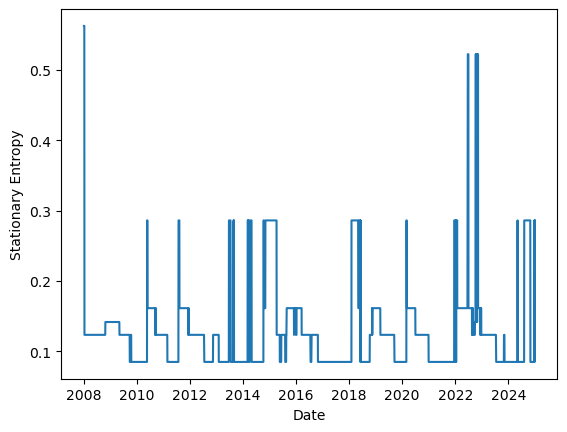

In [24]:
df = entropy.build_stationary_entropy(df, entropy_vector)

sns.lineplot(data = df['Stationary Entropy'])

<Axes: xlabel='Date', ylabel='Expanding Entropy'>

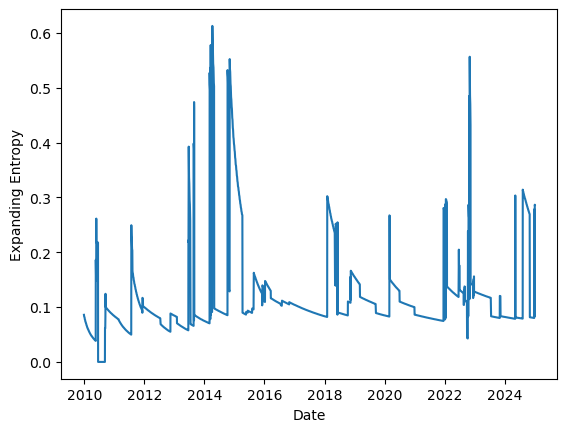

In [25]:
df = entropy.build_expanding_entropy(df)

sns.lineplot(data = df['Expanding Entropy'])

In [26]:
df['Expanding Entropy'].describe()

count    3778.000000
mean        0.117199
std         0.079729
min        -0.000000
25%         0.081160
50%         0.092218
75%         0.121605
max         0.612869
Name: Expanding Entropy, dtype: float64

In [27]:
df[[f'T-Stat_200', 'Log Return']].corr()

,T-Stat_200,Log Return
T-Stat_200,1.000000,-0.024316
Log Return,-0.024316,1.000000


In [28]:
df[['Volatility', 'Log Return']].corr()

,Volatility,Log Return
Volatility,1.000000,0.002394
Log Return,0.002394,1.000000


In [29]:
df[[f'T-Stat_200', 'Forward Return']].corr()

,T-Stat_200,Forward Return
T-Stat_200,1.000000,-0.018997
Forward Return,-0.018997,1.000000


In [30]:
df[['Volatility', 'Forward Return']].corr()

,Volatility,Forward Return
Volatility,1.000000,0.000393
Forward Return,0.000393,1.000000


In [31]:
from backtests import exposure

df = exposure.normalize_entropy(df)
df = exposure.normalize_tstat(df)
df = exposure.create_exposure(df)

In [32]:
df['Exposure'].describe()

count    4258.000000
mean        0.176976
std         0.378338
min        -0.837510
25%        -0.114067
50%         0.221289
75%         0.475854
max         0.921153
Name: Exposure, dtype: float64

In [33]:
(df['Exposure'].abs() > 0.8).mean()

0.026180458158017766

In [34]:
df['Trend'].describe()

count    4258.000000
mean        0.187196
std         0.401341
min        -0.874317
25%        -0.121940
50%         0.234732
75%         0.503254
max         0.952619
Name: Trend, dtype: float64

In [35]:
df['Confidence'].describe()

count    4278.000000
mean        0.942235
std         0.046800
min         0.657951
25%         0.935269
50%         0.950783
75%         0.957433
max         1.000000
Name: Confidence, dtype: float64

In [36]:
df['Exposure'].autocorr(lag = 1)

0.9395152393806372

In [37]:
df[['Exposure', 'Log Return']].corr()

,Exposure,Log Return
Exposure,1.000000,-0.018405
Log Return,-0.018405,1.000000


In [38]:
df[['Exposure', 'Forward Return']].corr()

,Exposure,Forward Return
Exposure,1.000000,-0.008272
Forward Return,-0.008272,1.000000


In [39]:
df.groupby('Vol State')['Exposure'].mean()

Vol State
0    0.221534
1    0.030856
Name: Exposure, dtype: float64

In [40]:
df.groupby('Regime')['Exposure'].mean()

Regime
-1.0   -0.085699
 0.0    0.115247
 1.0    0.252491
Name: Exposure, dtype: float64

In [41]:
df['Exposure Change'] = df['Exposure'].diff().abs()
df['Exposure Change'].mean()

0.0986986514742979

Text(0, 0.5, 'Exposure')

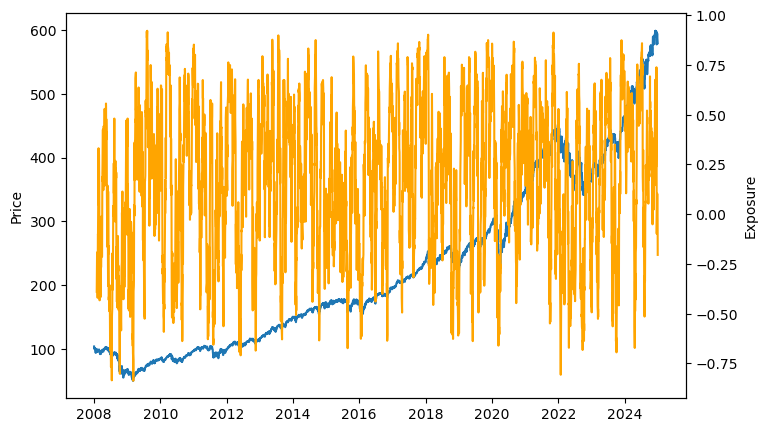

In [42]:
fig, ax1 = plt.subplots(figsize = (8, 5))

ax1.plot(df['Price'], label = 'Price')
ax1.set_ylabel('Price')
ax2 = ax1.twinx()
ax2.plot(df['Exposure'], label = 'Exposure', color = 'Orange')
ax2.set_ylabel('Exposure')

Text(0, 0.5, 'Exposure')

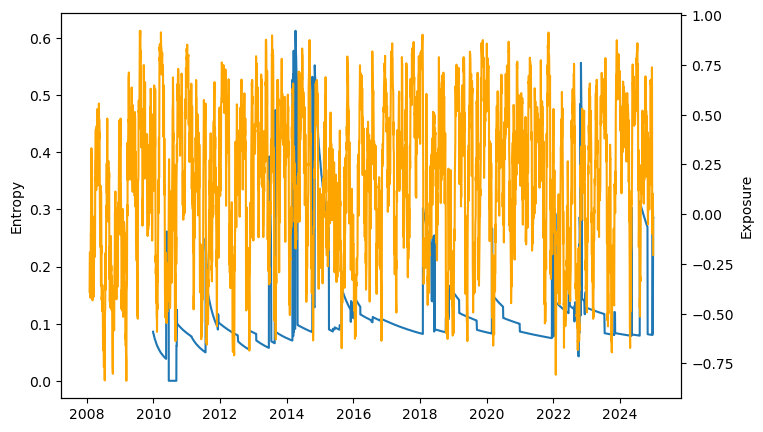

In [43]:
fig, ax1 = plt.subplots(figsize = (8, 5))

ax1.plot(df['Expanding Entropy'], label = 'Entropy')
ax1.set_ylabel('Entropy')
ax2 = ax1.twinx()
ax2.plot(df['Exposure'], label = 'Exposure', color = 'Orange')
ax2.set_ylabel('Exposure')

Text(0, 0.5, 'Exposure')

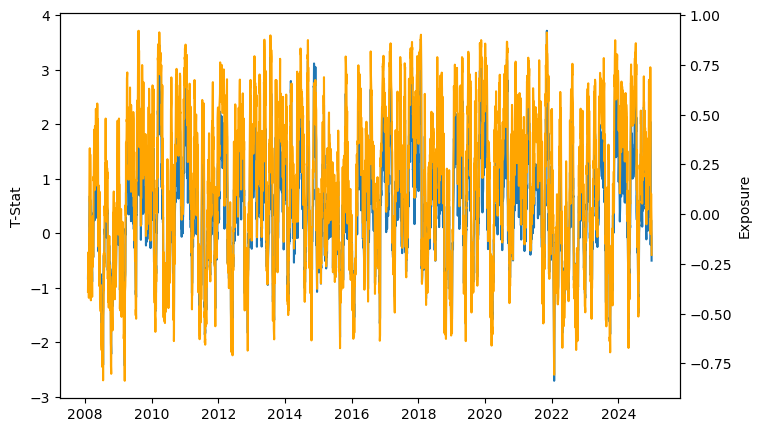

In [44]:
fig, ax1 = plt.subplots(figsize = (8, 5))

ax1.plot(df['T-Stat_20'], label = 'T-Stat-20')
ax1.set_ylabel('T-Stat')
ax2 = ax1.twinx()
ax2.plot(df['Exposure'], label = 'Exposure', color = 'Orange')
ax2.set_ylabel('Exposure')

<Axes: xlabel='Date'>

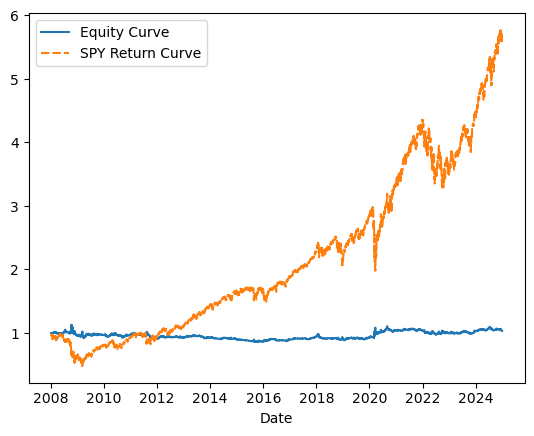

In [45]:
from backtests import backtest

df = backtest.run_backtest(df)
sns.lineplot(data = df[['Equity Curve', 'SPY Return Curve']])

<Axes: xlabel='Date', ylabel='Exposure'>

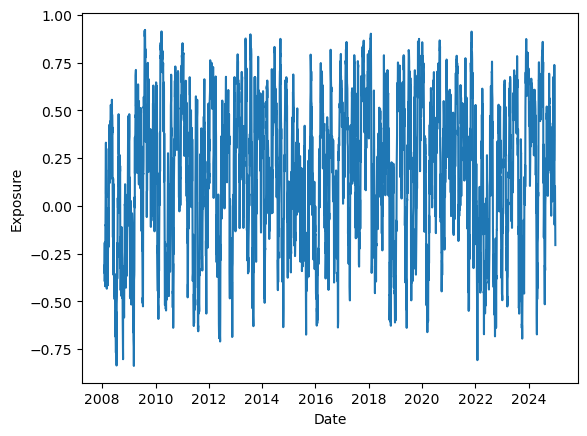

In [46]:
sns.lineplot(data = df['Exposure'])

In [47]:
(df['Exposure'] < 0).mean()

0.32515194015895277

In [48]:
df['Exposure'].corr(df['Pct Return'].shift(-1))

-0.013712967084870789

In [49]:
df['Expanding Entropy'].corr(df['Forward Vol'])

0.1424177465952223

<Axes: xlabel='Date'>

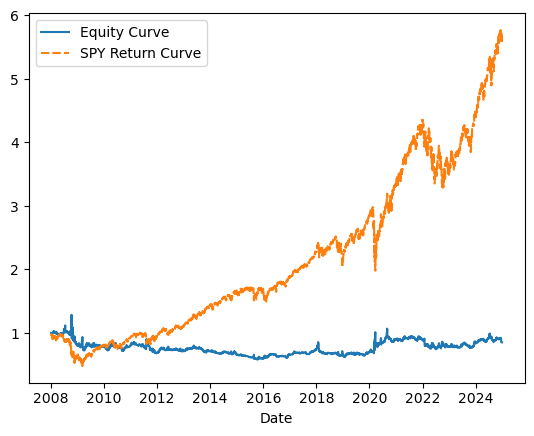

In [50]:
df['Exposure'] = df['T-Stat_20']
df['Exposure'].clip(0, 1)

df = backtest.run_backtest(df)
sns.lineplot(data = df[['Equity Curve', 'SPY Return Curve']])

In [51]:
(df['Exposure'] < 0).mean()

0.32515194015895277

<Axes: xlabel='Date'>

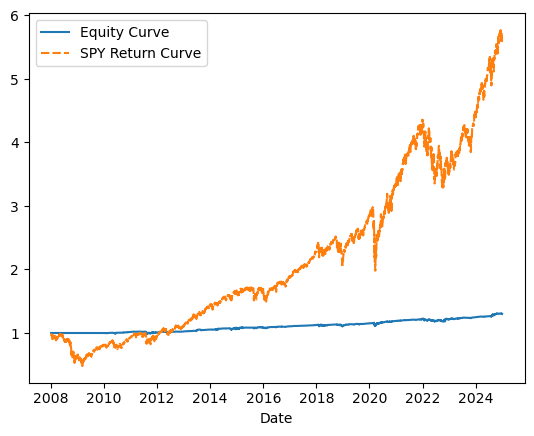

In [52]:
df['Exposure'] = df['Expanding Entropy']

df = backtest.run_backtest(df)
sns.lineplot(data = df[['Equity Curve', 'SPY Return Curve']])

In [53]:
import pandas as pd

df['Entropy Bins'] = pd.cut(df['Expanding Entropy'], bins = [0, 0.15, 0.4, 1], labels = ['Low', 'Mid', 'High'])

df.groupby('Entropy Bins')['Forward Vol'].mean().reset_index()

/var/folders/qd/xclxh05s0x9509nblm6z434w0000gp/T/ipykernel_71790/93630667.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Entropy Bins')['Forward Vol'].mean().reset_index()


,Entropy Bins,Forward Vol
0,Low,0.009291
1,Mid,0.011220
2,High,0.009210


<Axes: xlabel='Date'>

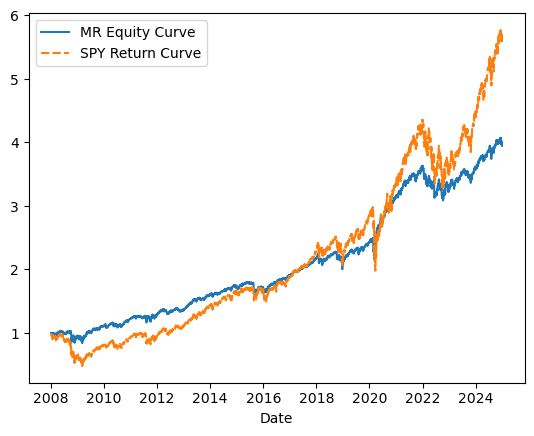

In [54]:
from backtests import mean_reversion
from features import zscore

df = zscore.calculate_zscore(df)
df = mean_reversion.generate_signal(df)
df = mean_reversion.mr_backtest(df)
sns.lineplot(data = df[['MR Equity Curve', 'SPY Return Curve']])

In [55]:
from evaluation import metrics

print(f"Mean-reversion-only Sharpe: {metrics.calculate_sharpe(df['MR Return'])}")
print(f"Mean-reversion-only max drawdown: {metrics.calculate_max_drawdown(df['MR Return'])}")

Mean-reversion-only Sharpe: 0.7752744068953508
Mean-reversion-only max drawdown: -0.18263233159137615


<Axes: xlabel='Date'>

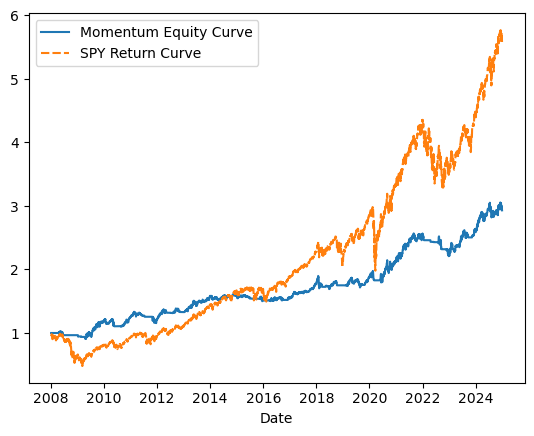

In [56]:
from backtests import momentum_backtest
from features import momentum

df = momentum.calculate_momentum(df)
df = momentum_backtest.generate_signal(df)
df = momentum_backtest.momentum_backtest(df)
sns.lineplot(data = df[['Momentum Equity Curve', 'SPY Return Curve']])

In [57]:
print(f"Momentum-only Sharpe: {metrics.calculate_sharpe(df['Momentum Return'])}")
print(f"Momentum-only max drawdown: {metrics.calculate_max_drawdown(df['Momentum Return'])}")

Momentum-only Sharpe: 0.6995054255317473
Momentum-only max drawdown: -0.13912952585603147


In [58]:
df['Momentum Signal'].describe()

count    4218.000000
mean        0.601921
std         0.428168
min         0.000000
25%         0.000000
50%         0.793323
75%         1.000000
max         1.000000
Name: Momentum Signal, dtype: float64

In [59]:
df['Momentum'].describe()

count    4218.000000
mean        0.025505
std         0.079841
min        -0.527698
25%        -0.001938
50%         0.039666
75%         0.071307
max         0.334966
Name: Momentum, dtype: float64

In [60]:
print(f"SPY Sharpe: {metrics.calculate_sharpe(df['Pct Return'])}")
print(f"SPY max drawdown: {metrics.calculate_max_drawdown(df['Pct Return'])}")

SPY Sharpe: 0.6072655766971308
SPY max drawdown: -0.5148146262318845


<Axes: xlabel='Date'>

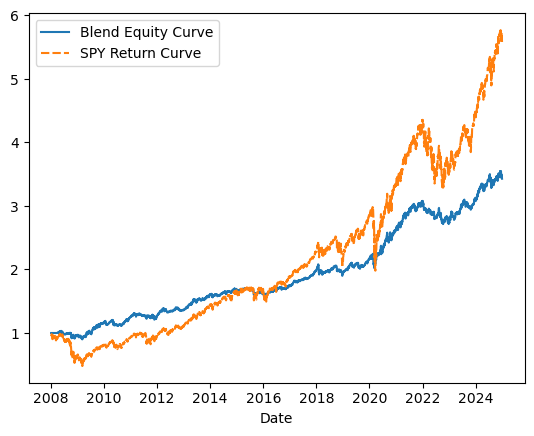

In [61]:
from backtests import blend_signal

df = blend_signal.generate_signal(df)
df = blend_signal.blended_backtest(df)
sns.lineplot(data = df[['Blend Equity Curve', 'SPY Return Curve']])

In [62]:
print(f"Blend Sharpe: {metrics.calculate_sharpe(df['Blend Return'])}")
print(f"Blend max drawdown: {metrics.calculate_max_drawdown(df['Blend Return'])}")

Blend Sharpe: 0.8624150500266342
Blend max drawdown: -0.1273559824629101


In [63]:
print(df['Confidence'].describe())
print(df['State'].value_counts())

count    4278.000000
mean        0.942235
std         0.046800
min         0.657951
25%         0.935269
50%         0.950783
75%         0.957433
max         1.000000
Name: Confidence, dtype: float64
State
1.0_0     1836
0.0_0     1298
0.0_1      637
1.0_1      331
-1.0_0     145
-1.0_1      27
nan_0        4
Name: count, dtype: int64


[*********************100%***********************]  1 of 1 completed
/Users/ak/Documents/GitHub/entropy-trading/regime/state_labels.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .apply(lambda x: x[-1] if (x == x[-1]).sum() >= window else np.nan)


<Axes: xlabel='Date'>

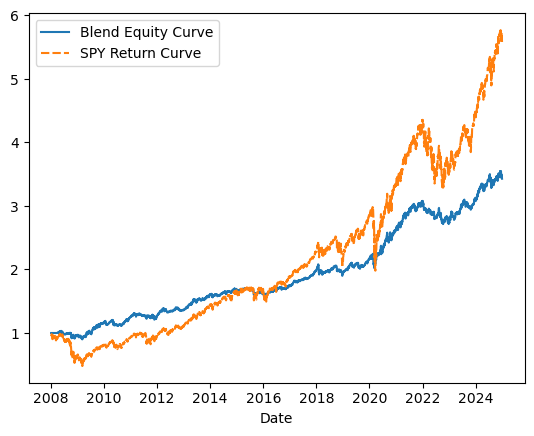

In [64]:
from pipeline import run

test = run.run_pipeline('SPY')

sns.lineplot(data = df[['Blend Equity Curve', 'SPY Return Curve']])

In [70]:
print(f'Blend annualized returns: {metrics.calculate_annualized_returns(df['Blend Return'])}')
print(f'Blend Sortino ratio: {metrics.calculate_sortino(df['Blend Return'])}')
print(f'Blend Calmar ratio: {metrics.calculate_calmar(df['Blend Return'])}')

Blend annualized returns: 0.07516982262832506
Blend Sortino ratio: 1.0566886144009486
Blend Calmar ratio: 0.590233934634494


In [72]:
print(f'SPY annualized returns: {metrics.calculate_annualized_returns(df['Pct Return'])}')
print(f'SPY Sortino ratio: {metrics.calculate_sortino(df['Pct Return'])}')
print(f'SPY Calmar ratio: {metrics.calculate_calmar(df['Pct Return'])}')

SPY annualized returns: 0.10645887616244987
SPY Sortino ratio: 0.7382494792072125
SPY Calmar ratio: 0.20679069851154214


In [73]:
df

,Price,Log Return,T-Stat_200,Volatility,Vol State,Regime,Forward Return,Forward Vol,State,Next State,...,MR Equity Curve,Momentum,Momentum Signal,Momentum Return,Momentum Equity Curve,w_mom,w_mr,Blend Signal,Blend Return,Blend Equity Curve
Date,,,,,,,,,,,,,,,,,,,,,
2008-01-03,103.728157,-0.000483,NaN,NaN,0,NaN,-0.024812,NaN,nan_0,nan_0,...,1.000000,NaN,NaN,0.000000,1.000000,0.5,0.5,NaN,0.000000,1.000000
2008-01-04,101.186165,-0.024812,NaN,NaN,0,NaN,-0.000850,NaN,nan_0,nan_0,...,1.000000,NaN,NaN,0.000000,1.000000,0.5,0.5,NaN,0.000000,1.000000
2008-01-07,101.100182,-0.000850,NaN,NaN,0,NaN,-0.016280,NaN,nan_0,nan_0,...,1.000000,NaN,NaN,0.000000,1.000000,0.5,0.5,NaN,0.000000,1.000000
2008-01-08,99.467598,-0.016280,NaN,NaN,0,NaN,0.010456,NaN,nan_0,0.0_0,...,1.000000,NaN,NaN,0.000000,1.000000,0.5,0.5,NaN,0.000000,1.000000
2008-01-09,100.513039,0.010456,NaN,NaN,0,0.0,0.006533,NaN,0.0_0,0.0_0,...,1.000000,NaN,NaN,0.000000,1.000000,0.5,0.5,NaN,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,594.320801,0.011054,1.432930,0.007806,1,1.0,0.000067,0.007909,1.0_1,1.0_1,...,4.014289,0.043188,0.863768,0.009601,3.003916,0.5,0.5,0.532030,0.005914,3.495630
2024-12-26,594.360352,0.000067,1.531647,0.007909,1,1.0,-0.010582,0.007804,1.0_1,1.0_0,...,4.014351,0.050243,1.000000,0.000067,3.004116,0.5,0.5,0.538810,0.000036,3.495755
2024-12-27,588.103821,-0.010582,1.443915,0.007804,0,1.0,-0.011477,0.007945,1.0_0,1.0_1,...,3.993031,0.059308,1.000000,-0.010526,2.972493,0.5,0.5,0.729199,-0.007676,3.468922
